# Train a Mobile TFLite Package Damage Classifier from Roboflow

This Colab notebook trains a phone-friendly package classifier for Flutter/TFLite deployment. It uses a compact MobileNetV3 model instead of ViT-base, then exports float32, float16, and optional int8 `.tflite` models.

Goal: keep the deployable model under 50 MB and fast enough for local phone inference, while staying as close as possible to the ViT/Roboflow accuracy.

## 1. Install dependencies

In [1]:
!pip -q install -U roboflow tensorflow scikit-learn matplotlib seaborn pillow

In [2]:
import os
import json
import shutil
import time
from collections import Counter
from pathlib import Path
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
tf.keras.utils.set_random_seed(SEED)
sns.set_theme(style='whitegrid')

print('TensorFlow:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download the Roboflow dataset

Use the same Roboflow workspace, project slug, and dataset version that produced your ViT result. For image classification, `folder` is the expected export format.

In [3]:
# Example Roboflow URL shape:
# https://universe.roboflow.com/<WORKSPACE>/<PROJECT>/dataset/<VERSION>

WORKSPACE = 'workspace-fbizk'      # e.g. 'my-school-project'
PROJECT = 'damaged-box-detection-2-classes'     # e.g. 'package-damage-classifier'
VERSION = 1                       # e.g. 3
EXPORT_FORMAT = 'folder'

assert WORKSPACE != 'YOUR_WORKSPACE', 'Set WORKSPACE first.'
assert PROJECT != 'YOUR_PROJECT_SLUG', 'Set PROJECT first.'

In [4]:
from roboflow import Roboflow

api_key = os.environ.get('WBhh6jyHHZZ6iU1N2atG') or getpass('Roboflow API key: ')
rf = Roboflow(api_key=api_key)
project = rf.workspace(WORKSPACE).project(PROJECT)
version = project.version(VERSION)
dataset = version.download(EXPORT_FORMAT)

DATASET_DIR = Path(dataset.location)
print('Dataset downloaded to:', DATASET_DIR)

Roboflow API key: ··········
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Damaged-Box-Detection-(2-classes)-1 in folder:: 100%|██████████| 1662/1662 [00:00<00:00, 4912.98it/s]

Dataset downloaded to: /content/Damaged-Box-Detection-(2-classes)-1


## 3. Inspect dataset layout and class balance

In [5]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def count_images(path: Path) -> int:
    return sum(1 for p in path.rglob('*') if p.suffix.lower() in IMAGE_EXTENSIONS)

def summarize_tree(root: Path):
    print(f'Root: {root}')
    for child in sorted([p for p in root.iterdir() if p.is_dir()]):
        print(f'- {child.name}/ ({count_images(child)} images)')
        for grandchild in sorted([p for p in child.iterdir() if p.is_dir()]):
            print(f'  - {grandchild.name}/ ({count_images(grandchild)} images)')

summarize_tree(DATASET_DIR)

Root: /content/Damaged-Box-Detection-(2-classes)-1
- test/ (166 images)
  - damaged/ (94 images)
  - intact/ (72 images)
- train/ (1162 images)
  - damaged/ (608 images)
  - intact/ (554 images)
- valid/ (332 images)
  - damaged/ (178 images)
  - intact/ (154 images)


In [6]:
def resolve_split_dir(root: Path, split_names):
    for split_name in split_names:
        candidate = root / split_name
        if candidate.exists() and count_images(candidate) > 0:
            return candidate
    return None

TRAIN_DIR = resolve_split_dir(DATASET_DIR, ['train', 'training'])
VAL_DIR = resolve_split_dir(DATASET_DIR, ['valid', 'validation', 'val'])
TEST_DIR = resolve_split_dir(DATASET_DIR, ['test', 'testing'])

assert TRAIN_DIR is not None, 'Could not find a train folder inside the Roboflow export.'

if VAL_DIR is None:
    print('No validation folder found. The notebook will create a validation split from train.')
else:
    print('Train:', TRAIN_DIR)
    print('Validation:', VAL_DIR)
    print('Test:', TEST_DIR)

class_names = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
assert len(class_names) == 2, f'Expected 2 class folders, found {len(class_names)}: {class_names}'
label_to_id = {name: i for i, name in enumerate(class_names)}
id_to_label = {i: name for name, i in label_to_id.items()}
print('Classes:', class_names)

Train: /content/Damaged-Box-Detection-(2-classes)-1/train
Validation: /content/Damaged-Box-Detection-(2-classes)-1/valid
Test: /content/Damaged-Box-Detection-(2-classes)-1/test
Classes: ['damaged', 'intact']


,split,damaged,intact
0,train,608,554
1,validation,178,154
2,test,94,72


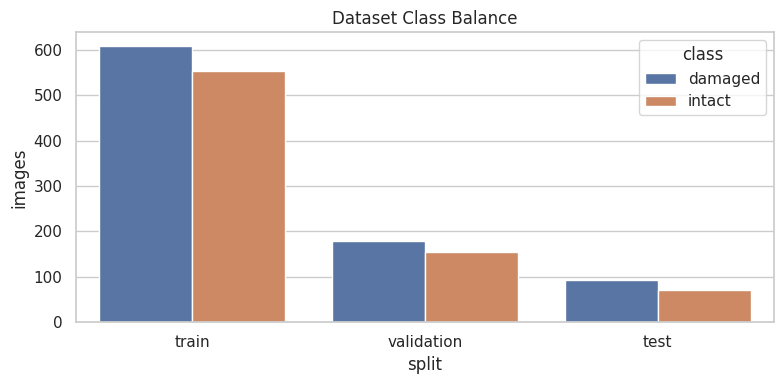

In [7]:
def class_counts_for_dir(split_dir: Path):
    if split_dir is None:
        return {}
    return {class_name: count_images(split_dir / class_name) for class_name in class_names}

counts_df = pd.DataFrame([
    {'split': 'train', **class_counts_for_dir(TRAIN_DIR)},
    {'split': 'validation', **class_counts_for_dir(VAL_DIR)},
    {'split': 'test', **class_counts_for_dir(TEST_DIR)},
]).fillna(0)

display(counts_df)
plot_df = counts_df.melt(id_vars='split', var_name='class', value_name='images')
plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x='split', y='images', hue='class')
plt.title('Dataset Class Balance')
plt.tight_layout()
plt.show()

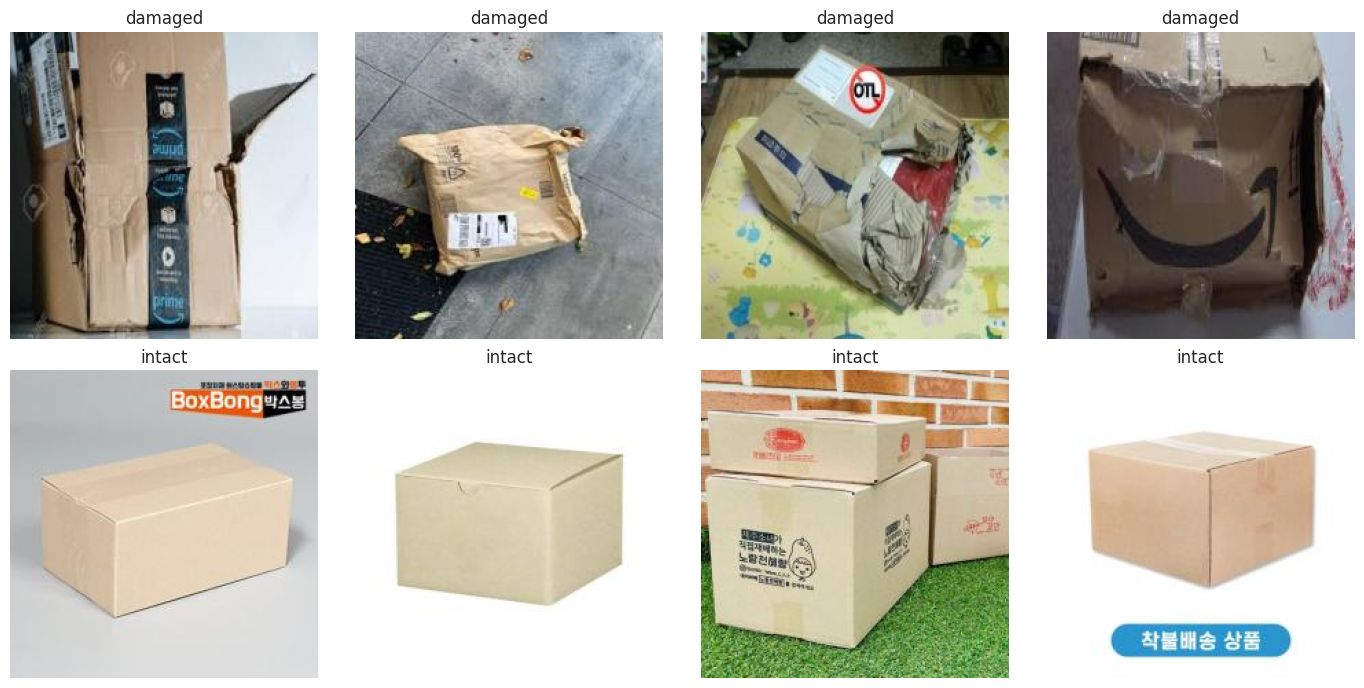

In [8]:
sample_paths = []
for class_name in class_names:
    sample_paths.extend(sorted((TRAIN_DIR / class_name).glob('*'))[:4])
sample_paths = [p for p in sample_paths if p.suffix.lower() in IMAGE_EXTENSIONS]

cols = 4
rows = max(1, int(np.ceil(len(sample_paths) / cols)))
plt.figure(figsize=(14, 3.5 * rows))
for i, path in enumerate(sample_paths):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(Image.open(path).convert('RGB'))
    plt.title(path.parent.name)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Build TensorFlow datasets

MobileNetV3 includes its own preprocessing layer when `include_preprocessing=True`, so the dataset keeps images in the normal `0..255` range.

In [9]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

if VAL_DIR is None:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        labels='inferred',
        label_mode='int',
        class_names=class_names,
        validation_split=0.2,
        subset='training',
        seed=SEED,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        labels='inferred',
        label_mode='int',
        class_names=class_names,
        validation_split=0.2,
        subset='validation',
        seed=SEED,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
    )
else:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        labels='inferred',
        label_mode='int',
        class_names=class_names,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        VAL_DIR,
        labels='inferred',
        label_mode='int',
        class_names=class_names,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

test_ds = None
if TEST_DIR is not None:
    test_ds = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,
        labels='inferred',
        label_mode='int',
        class_names=class_names,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
if test_ds is not None:
    test_ds = test_ds.prefetch(AUTOTUNE)

Found 1162 files belonging to 2 classes.
Found 332 files belonging to 2 classes.
Found 166 files belonging to 2 classes.


In [10]:
train_labels = []
for _, y in tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    class_names=class_names,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
):
    train_labels.extend(y.numpy().tolist())

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_names)),
    y=np.array(train_labels),
)
class_weight = {i: float(weight) for i, weight in enumerate(class_weights_array)}
print('Class weights:', {id_to_label[i]: round(class_weight[i], 3) for i in class_weight})

Found 1162 files belonging to 2 classes.
Class weights: {'damaged': 0.956, 'intact': 1.049}


## 5. Train MobileNetV3Large

This trains the classifier head first, then fine-tunes the upper part of the base model. If this is still too large or slow, switch `MODEL_FAMILY` to `MobileNetV3Small`.

In [11]:
MODEL_FAMILY = 'MobileNetV3Large'  # Options: 'MobileNetV3Large', 'MobileNetV3Small'
DROPOUT = 0.25
HEAD_EPOCHS = 8
FINE_TUNE_EPOCHS = 25
FINE_TUNE_AT = 120

def make_base_model(model_family):
    kwargs = dict(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet',
        include_preprocessing=True,
    )
    if model_family == 'MobileNetV3Small':
        return tf.keras.applications.MobileNetV3Small(**kwargs)
    if model_family == 'MobileNetV3Large':
        return tf.keras.applications.MobileNetV3Large(**kwargs)
    raise ValueError(f'Unsupported MODEL_FAMILY: {model_family}')

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal', seed=SEED),
    tf.keras.layers.RandomRotation(0.05, seed=SEED),
    tf.keras.layers.RandomZoom(0.10, seed=SEED),
    tf.keras.layers.RandomContrast(0.20, seed=SEED),
], name='augmentation')

base_model = make_base_model(MODEL_FAMILY)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image')
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(DROPOUT)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation='softmax', name='class_probs')(x)
model = tf.keras.Model(inputs, outputs, name='package_damage_mobilenetv3')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)
model.summary()

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "package_damage_mobilenetv3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probs (Dense)             │ (None, 2)              │         1,922 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,998,274 (11.44 MB)

 Trainable params: 1,922 (7.51 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 152ms/step - accuracy: 0.7487 - loss: 0.5276 - val_accuracy: 0.9006 - val_loss: 0.2730 - learning_rate: 0.0010
Epoch 2/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.8520 - loss: 0.3234 - val_accuracy: 0.9127 - val_loss: 0.2321 - learning_rate: 0.0010
Epoch 3/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8769 - loss: 0.3040 - val_accuracy: 0.9127 - val_loss: 0.2232 - learning_rate: 0.0010
Epoch 4/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8976 - loss: 0.2721 - val_accuracy: 0.9006 - val_loss: 0.2483 - learning_rate: 0.0010
Epoch 5/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8959 - loss: 0.2599 - val_accuracy: 0.9066 - val_loss: 0.2204 - learning_rate: 0.0010
Epoch 6/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.9010 - loss: 0.2545 - val_accuracy: 0.9096 - val_loss: 0.2284 - learning_rate: 0.0010
Epoch 7/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.9079 - loss: 0.2481 - val_accuracy

In [13]:
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 22s 182ms/step - accuracy: 0.8563 - loss: 0.3357 - val_accuracy: 0.9217 - val_loss: 0.2210 - learning_rate: 1.0000e-05
Epoch 2/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.8735 - loss: 0.3077 - val_accuracy: 0.9096 - val_loss: 0.2299 - learning_rate: 1.0000e-05
Epoch 3/25
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8792 - loss: 0.2468
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.8795 - loss: 0.2769 - val_accuracy: 0.9066 - val_loss: 0.2295 - learning_rate: 1.0000e-05
Epoch 4/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.8744 - loss: 0.2819 - val_accuracy: 0.9127 - val_loss: 0.2246 - learning_rate: 3.0000e-06
Epoch 5/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.8959 - loss: 0.2517 - val_accuracy: 0.9127 - val_loss: 0.2214 - learning_rate: 3.0000e-06
Epoch 6/25
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.918

## 6. Training curves and evaluation visuals

,accuracy,loss,val_accuracy,val_loss,learning_rate,phase,epoch
24,0.916523,0.222880,0.930723,0.186196,1.000000e-06,fine_tune,25
25,0.903614,0.228936,0.927711,0.185336,1.000000e-06,fine_tune,26
26,0.908778,0.224702,0.927711,0.184808,1.000000e-06,fine_tune,27
27,0.920826,0.218655,0.927711,0.184036,1.000000e-06,fine_tune,28
28,0.923408,0.218512,0.924699,0.183364,1.000000e-06,fine_tune,29


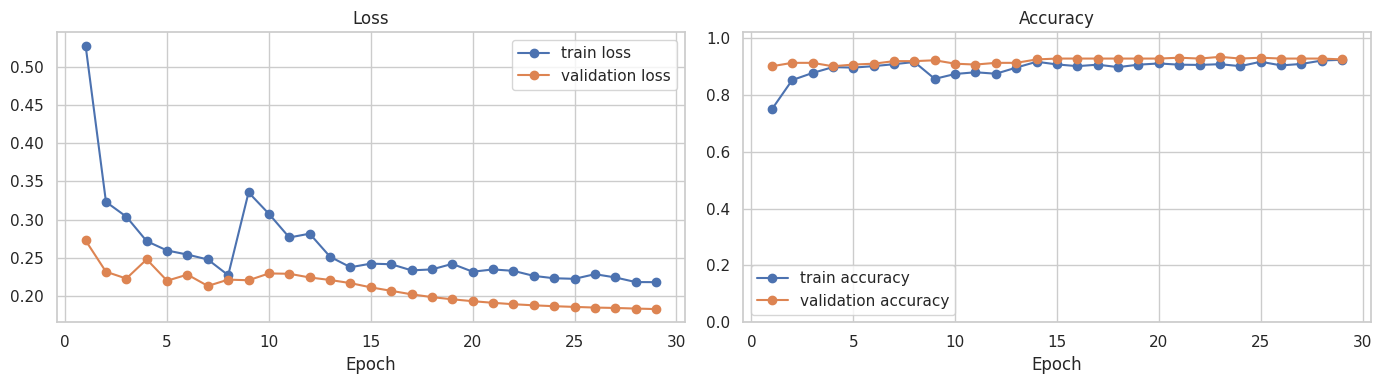

In [14]:
def combine_histories(*histories):
    frames = []
    epoch_offset = 0
    for name, history in histories:
        frame = pd.DataFrame(history.history)
        frame['phase'] = name
        frame['epoch'] = np.arange(len(frame)) + 1 + epoch_offset
        epoch_offset += len(frame)
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)

history_df = combine_histories(('head', history_head), ('fine_tune', history_fine))
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_df['epoch'], history_df['loss'], marker='o', label='train loss')
axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='validation loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['accuracy'], marker='o', label='train accuracy')
axes[1].plot(history_df['epoch'], history_df['val_accuracy'], marker='o', label='validation accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1.02)
axes[1].legend()
plt.tight_layout()
plt.show()


=== VALIDATION ===
              precision    recall  f1-score   support

     damaged       0.96      0.92      0.94       178
      intact       0.91      0.95      0.93       154

    accuracy                           0.93       332
   macro avg       0.93      0.94      0.93       332
weighted avg       0.93      0.93      0.93       332



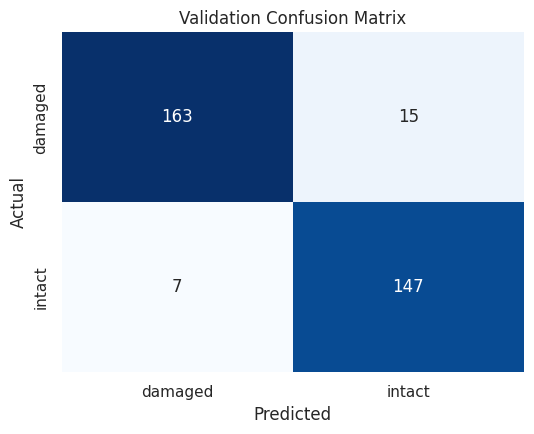


=== TEST ===
              precision    recall  f1-score   support

     damaged       0.97      0.83      0.90        94
      intact       0.81      0.97      0.89        72

    accuracy                           0.89       166
   macro avg       0.89      0.90      0.89       166
weighted avg       0.91      0.89      0.89       166



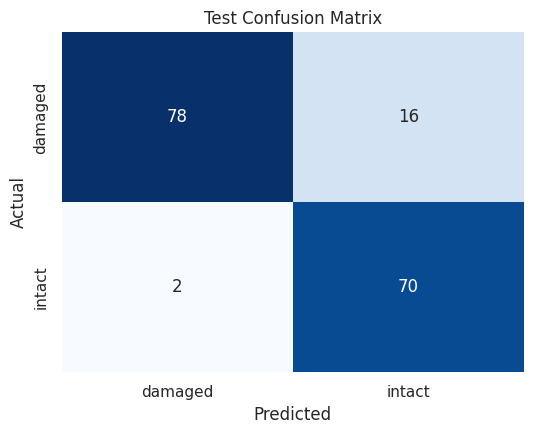

,split,accuracy,balanced_accuracy,macro_f1
0,validation,0.933735,0.935138,0.933581
1,test,0.891566,0.901005,0.891314


In [15]:
def collect_predictions(tf_dataset):
    y_true = []
    y_pred = []
    y_prob = []
    for images, labels_batch in tf_dataset:
        probs = model.predict(images, verbose=0)
        y_true.extend(labels_batch.numpy().tolist())
        y_pred.extend(np.argmax(probs, axis=1).tolist())
        y_prob.extend(probs.tolist())
    return np.array(y_true), np.array(y_pred), np.array(y_prob)

def evaluate_split(split_name, tf_dataset):
    y_true, y_pred, y_prob = collect_predictions(tf_dataset)
    print(f'\n=== {split_name.upper()} ===')
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar=False)
    plt.title(f'{split_name.title()} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return {
        'split': split_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
    }

val_results = evaluate_split('validation', val_ds)
test_results = evaluate_split('test', test_ds) if test_ds is not None else None

metrics_rows = [{k: v for k, v in val_results.items() if not k.startswith('y_')}]
if test_results is not None:
    metrics_rows.append({k: v for k, v in test_results.items() if not k.startswith('y_')})
metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)

In [16]:
VIT_BENCHMARK_ACCURACY = 0.94  # Update this if your ViT/Roboflow comparison value changes.
benchmark_df = metrics_df.copy()
benchmark_df['vit_benchmark_accuracy'] = VIT_BENCHMARK_ACCURACY
benchmark_df['accuracy_gap_vs_vit'] = benchmark_df['accuracy'] - VIT_BENCHMARK_ACCURACY
display(benchmark_df)

,split,accuracy,balanced_accuracy,macro_f1,vit_benchmark_accuracy,accuracy_gap_vs_vit
0,validation,0.933735,0.935138,0.933581,0.94,-0.006265
1,test,0.891566,0.901005,0.891314,0.94,-0.048434


## 7. Sample predictions

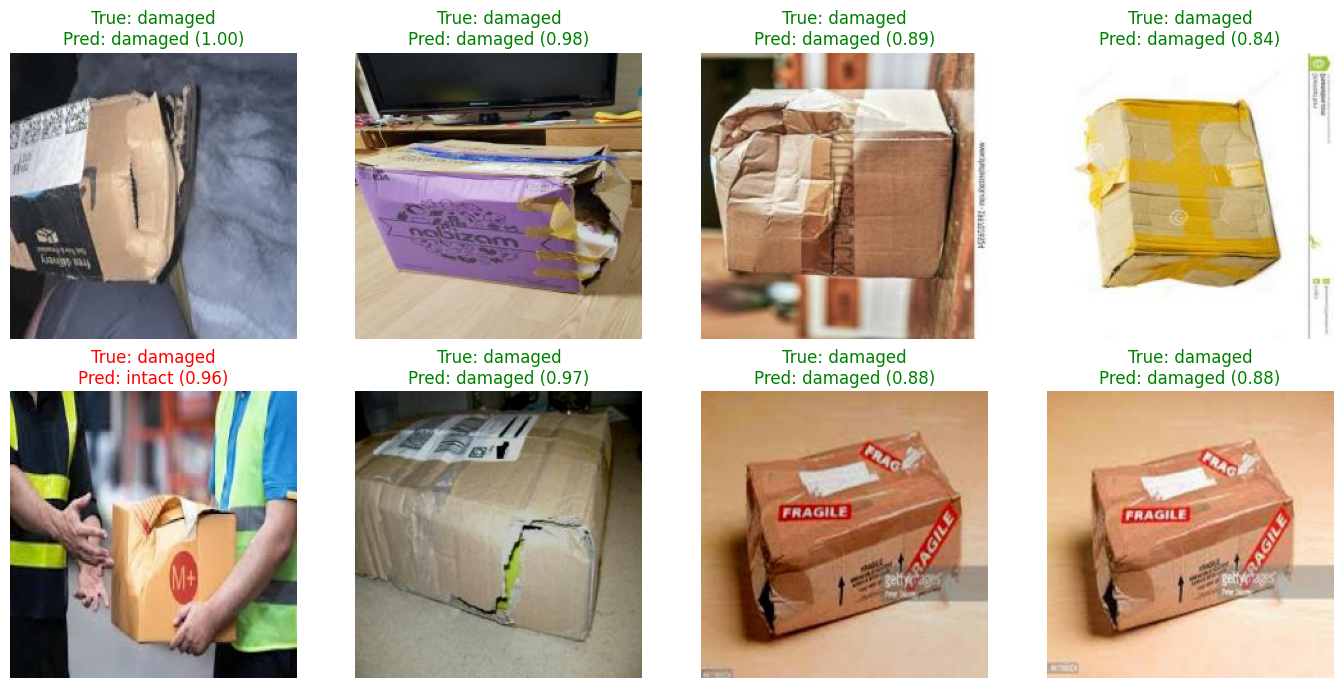

In [17]:
preview_ds = test_ds if test_ds is not None else val_ds
images_batch, labels_batch = next(iter(preview_ds))
probs_batch = model.predict(images_batch, verbose=0)
preds_batch = np.argmax(probs_batch, axis=1)

show_count = min(8, images_batch.shape[0])
plt.figure(figsize=(14, 7))
for i in range(show_count):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images_batch[i].numpy().astype('uint8'))
    true_label = id_to_label[int(labels_batch[i])]
    pred_label = id_to_label[int(preds_batch[i])]
    confidence = probs_batch[i][preds_batch[i]]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f'True: {true_label}\nPred: {pred_label} ({confidence:.2f})', color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 8. Export SavedModel and TFLite files

For Flutter, the most likely file to ship is the float16 `.tflite` model plus `labels.txt`. Keep the float32 file as a baseline and use int8 only if you need extra speed or smaller size.

In [20]:
EXPORT_DIR = Path('/content/mobile-package-classifier-export')
SAVEDMODEL_DIR = EXPORT_DIR / 'saved_model'
KERAS_MODEL_PATH = EXPORT_DIR / 'package_damage_classifier.keras'
TFLITE_FLOAT32_PATH = EXPORT_DIR / 'package_damage_float32.tflite'
TFLITE_FLOAT16_PATH = EXPORT_DIR / 'package_damage_float16.tflite'
TFLITE_INT8_PATH = EXPORT_DIR / 'package_damage_int8.tflite'
LABELS_PATH = EXPORT_DIR / 'labels.txt'

if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Export a deployment-only model. Do not export training augmentation layers;
# random augmentation ops are not supported by the native TFLite runtime.
inference_inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image')
x = base_model(inference_inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = model.get_layer('dropout')(x, training=False)
inference_outputs = model.get_layer('class_probs')(x)
inference_model = tf.keras.Model(
    inference_inputs,
    inference_outputs,
    name='package_damage_mobilenetv3_inference',
)

# Check that the clean export model matches the trained model with augmentation disabled.
check_images, _ = next(iter(val_ds))
train_probs = model(check_images[:8], training=False).numpy()
infer_probs = inference_model(check_images[:8], training=False).numpy()
print('Max prediction difference:', np.max(np.abs(train_probs - infer_probs)))

inference_model.save(str(KERAS_MODEL_PATH))
try:
    inference_model.export(str(SAVEDMODEL_DIR))
except AttributeError:
    tf.saved_model.save(inference_model, str(SAVEDMODEL_DIR))

LABELS_PATH.write_text('\n'.join(class_names) + '\n')

print('Saved Keras inference model:', KERAS_MODEL_PATH)
print('SavedModel:', SAVEDMODEL_DIR)
print('Labels:', LABELS_PATH)


Max prediction difference: 0.0
Saved artifact at '/content/mobile-package-classifier-export/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  132648938544912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132647064149968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132647064149776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132647064148624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132647064150544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132647064149584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132647064153616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132647064153808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132647064148048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132647064150736: Tensor

In [21]:
def write_tflite_model(converter, output_path):
    model_bytes = converter.convert()
    output_path.write_bytes(model_bytes)
    return output_path.stat().st_size / (1024 * 1024)

# Float32 baseline.
converter = tf.lite.TFLiteConverter.from_saved_model(str(SAVEDMODEL_DIR))
float32_mb = write_tflite_model(converter, TFLITE_FLOAT32_PATH)

# Float16 optimized model. Recommended first choice for Flutter deployment.
converter = tf.lite.TFLiteConverter.from_saved_model(str(SAVEDMODEL_DIR))
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
float16_mb = write_tflite_model(converter, TFLITE_FLOAT16_PATH)

print(f'Float32 TFLite: {float32_mb:.2f} MB')
print(f'Float16 TFLite: {float16_mb:.2f} MB')

Float32 TFLite: 11.39 MB
Float16 TFLite: 5.79 MB


In [23]:
# Optional full int8 export. This is smaller/faster, but may require extra Flutter input/output handling.
EXPORT_INT8 = True

def representative_dataset():
    sample_count = 0
    for images, _ in train_ds.unbatch().batch(1).take(200):
        yield [tf.cast(images, tf.float32)]
        sample_count += 1

if EXPORT_INT8:
    try:
        converter = tf.lite.TFLiteConverter.from_saved_model(str(SAVEDMODEL_DIR))
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = representative_dataset
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.uint8
        converter.inference_output_type = tf.uint8
        int8_mb = write_tflite_model(converter, TFLITE_INT8_PATH)
        print(f'Int8 TFLite: {int8_mb:.2f} MB')
    except Exception as exc:
        int8_mb = None
        print('Int8 export failed, but float32/float16 exports are still usable.')
        print(type(exc).__name__, exc)
else:
    int8_mb = None
    print('Skipped int8 export.')

Int8 TFLite: 3.37 MB


## 9. TFLite size and latency sanity check

Colab latency is not the same as a phone, but this catches obvious problems. The float16 model is usually the simplest Flutter target because it still accepts float input.

In [25]:
def inspect_tflite_model(model_path):
    # Colab's default XNNPACK delegate can fail on some int8 graphs.
    # Fall back to the reference resolver.
    try:
        interpreter = tf.lite.Interpreter(model_path=str(model_path))
        interpreter.allocate_tensors()
    except RuntimeError as first_error:
        print(f'Default TFLite runtime failed for {model_path.name}; retrying without acceleration delegate.')
        print(type(first_error).__name__, first_error)
        interpreter = tf.lite.Interpreter(
            model_path=str(model_path),
            experimental_op_resolver_type=tf.lite.experimental.OpResolverType.BUILTIN_REF,
            experimental_preserve_all_tensors=True,
        )
        interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    return interpreter, input_details, output_details

def prepare_tflite_input(image_tensor, input_details):
    image = tf.image.resize(image_tensor, (IMG_SIZE, IMG_SIZE)).numpy()
    image = np.expand_dims(image, axis=0)

    if input_details['dtype'] == np.uint8:
        scale, zero_point = input_details['quantization']
        if scale > 0:
            image = image / scale + zero_point
        image = np.clip(np.round(image), 0, 255).astype(np.uint8)
    else:
        image = image.astype(input_details['dtype'])

    return image

def run_latency_test(model_path, runs=50):
    interpreter, input_details, output_details = inspect_tflite_model(model_path)
    image_batch, _ = next(iter(val_ds))
    sample_input = prepare_tflite_input(image_batch[0], input_details)

    for _ in range(5):
        interpreter.set_tensor(input_details['index'], sample_input)
        interpreter.invoke()

    times = []
    for _ in range(runs):
        start = time.perf_counter()
        interpreter.set_tensor(input_details['index'], sample_input)
        interpreter.invoke()
        times.append((time.perf_counter() - start) * 1000)

    return {
        'model': model_path.name,
        'size_mb': model_path.stat().st_size / (1024 * 1024),
        'input_dtype': str(input_details['dtype']),
        'output_dtype': str(output_details['dtype']),
        'mean_latency_ms_colab': float(np.mean(times)),
        'p95_latency_ms_colab': float(np.percentile(times, 95)),
        'note': 'Colab timing only; phone timing may differ',
    }

latency_rows = []

for tflite_path in [TFLITE_FLOAT32_PATH, TFLITE_FLOAT16_PATH]:
    try:
        latency_rows.append(run_latency_test(tflite_path))
    except Exception as exc:
        latency_rows.append({
            'model': tflite_path.name,
            'size_mb': tflite_path.stat().st_size / (1024 * 1024),
            'error': f'{type(exc).__name__}: {exc}',
        })

if EXPORT_INT8 and TFLITE_INT8_PATH.exists():
    try:
        latency_rows.append(run_latency_test(TFLITE_INT8_PATH))
    except Exception as exc:
        latency_rows.append({
            'model': TFLITE_INT8_PATH.name,
            'size_mb': TFLITE_INT8_PATH.stat().st_size / (1024 * 1024),
            'error': f'{type(exc).__name__}: {exc}',
            'note': 'Int8 file was exported, but Colab could not allocate it for latency testing. Use float16 first for Flutter.',
        })

latency_df = pd.DataFrame(latency_rows)
display(latency_df)


Default TFLite runtime failed for package_damage_int8.tflite; retrying without acceleration delegate.
RuntimeError failed to create XNNPACK runtimeNode number 124 (TfLiteXNNPackDelegate) failed to prepare.


,model,size_mb,input_dtype,output_dtype,mean_latency_ms_colab,p95_latency_ms_colab,note
0,package_damage_float32.tflite,11.390297,<class 'numpy.float32'>,<class 'numpy.float32'>,26.632629,39.852471,Colab timing only; phone timing may differ
1,package_damage_float16.tflite,5.786434,<class 'numpy.float32'>,<class 'numpy.float32'>,31.139912,47.989956,Colab timing only; phone timing may differ
2,package_damage_int8.tflite,3.369057,<class 'numpy.uint8'>,<class 'numpy.uint8'>,189.847814,198.075647,Colab timing only; phone timing may differ


In [26]:
export_summary = {
    'model_family': MODEL_FAMILY,
    'image_size': IMG_SIZE,
    'classes': class_names,
    'metrics': json.loads(metrics_df.to_json(orient='records')),
    'tflite_latency_and_size': json.loads(latency_df.to_json(orient='records')),
    'recommended_flutter_model': str(TFLITE_FLOAT16_PATH),
    'labels_file': str(LABELS_PATH),
}

summary_path = EXPORT_DIR / 'export_summary.json'
summary_path.write_text(json.dumps(export_summary, indent=2))
print('Export folder:', EXPORT_DIR)
print('Recommended Flutter files:')
print('-', TFLITE_FLOAT16_PATH)
print('-', LABELS_PATH)
print('Summary:', summary_path)

Export folder: /content/mobile-package-classifier-export
Recommended Flutter files:
- /content/mobile-package-classifier-export/package_damage_float16.tflite
- /content/mobile-package-classifier-export/labels.txt
Summary: /content/mobile-package-classifier-export/export_summary.json


## 10. Optional: copy export folder to Google Drive

In [27]:
SAVE_TO_DRIVE = True

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_dir = Path('/content/drive/MyDrive/mobile-package-classifier-export')
    if drive_dir.exists():
        shutil.rmtree(drive_dir)
    shutil.copytree(EXPORT_DIR, drive_dir)
    print('Copied export folder to:', drive_dir)

Mounted at /content/drive
Copied export folder to: /content/drive/MyDrive/mobile-package-classifier-export


## 11. Flutter integration notes

Use `package_damage_float16.tflite` first. It should accept a float image tensor shaped `[1, 224, 224, 3]` in the normal `0..255` range because preprocessing is included inside the model. Use `labels.txt` to map output indices back to class names.

If you switch to the int8 model, inspect `latency_df` for input/output dtypes and quantization details. Int8 is smaller, but the Flutter code must handle quantized tensors correctly.